# DATA 602 Project 1: Model Training and Fine-Tuning

## Setup

In [1]:
!python -m pip install -q scikit-learn sklearn_evaluation pyarrow

### Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from typing import Tuple, Any
import warnings
import os
from scipy.stats import randint
from sklearn.decomposition import PCA
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score, 
    classification_report, 
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_score, 
    recall_score, 
    f1_score, 
    roc_auc_score, 
    roc_curve, 
    precision_recall_curve
)
from sklearn_evaluation import plot
from sklearn.preprocessing import StandardScaler, MinMaxScaler, FunctionTransformer, QuantileTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.utils import resample

### Configurations

In [3]:
sns.set_style('darkgrid')

In [4]:
warnings.filterwarnings('ignore')

## Load Train and Test Data

In [5]:
X_train = pd.read_csv("../datasets/raw/train.csv")
X_test = pd.read_csv('../datasets/raw/test.csv')

In [6]:
X_train.shape, X_test.shape

((103904, 25), (25976, 25))

In [7]:
# Analyze split ratio (goal is an 80/20 train/test split)
X_len = len(X_train) + len(X_test)
round(len(X_train) / X_len, 2), round(len(X_test) / X_len, 2)

(0.8, 0.2)

We can see that the test/train split has a perfect 80/20 split and we can proceed.

## Clean Train Data

### Remove Unnecessary Columns: Unnamed: 0 , 'id' columns are not necessary for analysis.

In [8]:
X_train.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [9]:
X_train = X_train.drop(columns=['Unnamed: 0','id'])
X_test = X_test.drop(columns=['Unnamed: 0','id'])

In [10]:
X_train.columns

Index(['Gender', 'Customer Type', 'Age', 'Type of Travel', 'Class',
       'Flight Distance', 'Inflight wifi service',
       'Departure/Arrival time convenient', 'Ease of Online booking',
       'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort',
       'Inflight entertainment', 'On-board service', 'Leg room service',
       'Baggage handling', 'Checkin service', 'Inflight service',
       'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes',
       'satisfaction'],
      dtype='object')

### Formatting Column Names

In [11]:
# Function to convert column names to uppercase and snake_case
X_train.columns = X_train.columns.str.upper().str.replace(' ', '_').str.replace('/', '_')
X_test.columns = X_test.columns.str.upper().str.replace(' ', '_').str.replace('/', '_')

# Display the updated column names
print(X_train.columns)

Index(['GENDER', 'CUSTOMER_TYPE', 'AGE', 'TYPE_OF_TRAVEL', 'CLASS',
       'FLIGHT_DISTANCE', 'INFLIGHT_WIFI_SERVICE',
       'DEPARTURE_ARRIVAL_TIME_CONVENIENT', 'EASE_OF_ONLINE_BOOKING',
       'GATE_LOCATION', 'FOOD_AND_DRINK', 'ONLINE_BOARDING', 'SEAT_COMFORT',
       'INFLIGHT_ENTERTAINMENT', 'ON-BOARD_SERVICE', 'LEG_ROOM_SERVICE',
       'BAGGAGE_HANDLING', 'CHECKIN_SERVICE', 'INFLIGHT_SERVICE',
       'CLEANLINESS', 'DEPARTURE_DELAY_IN_MINUTES', 'ARRIVAL_DELAY_IN_MINUTES',
       'SATISFACTION'],
      dtype='object')


### Formatting row values

In [12]:
for column in X_train.columns:
    unique_values = X_train[column].unique()
    print(f"Unique values in '{column}': {unique_values}\n")

# Update 'CUSTOMER_TYPE'
# X_train['CUSTOMER_TYPE'] = X_train['CUSTOMER_TYPE'].replace({
#     'disloyal Customer': 'Disloyal',
#     'Loyal Customer': 'Loyal'
# })

# # Update 'TYPE_OF_TRAVEL'
# X_train['TYPE_OF_TRAVEL'] = X_train['TYPE_OF_TRAVEL'].replace({
#     'Personal Travel': 'Personal',
#     'Business travel': 'Business'
# })

# Update 'SATISFACTION'
# X_train['SATISFACTION'] = X_train['SATISFACTION'].replace({
#     'satisfied': 'Satisfied',
#     'neutral or dissatisfied': 'Neutral or Dissatisfied'
# })

Unique values in 'GENDER': ['Male' 'Female']

Unique values in 'CUSTOMER_TYPE': ['Loyal Customer' 'disloyal Customer']

Unique values in 'AGE': [13 25 26 61 47 52 41 20 24 12 53 33 45 38  9 17 43 58 23 57 49 36 22 31
 15 35 67 37 40 34 39 50 29 54 21 28 27 69 60 48 59 46 30 66 64 44 51 32
 19 42 16 11 62  8 56 68 55 18 65 72 70 63 10  7 14 80 74 71 85 73 76 77
 75 79 78]

Unique values in 'TYPE_OF_TRAVEL': ['Personal Travel' 'Business travel']

Unique values in 'CLASS': ['Eco Plus' 'Business' 'Eco']

Unique values in 'FLIGHT_DISTANCE': [ 460  235 1142 ...  974 1479  400]

Unique values in 'INFLIGHT_WIFI_SERVICE': [3 2 4 1 5 0]

Unique values in 'DEPARTURE_ARRIVAL_TIME_CONVENIENT': [4 2 5 3 1 0]

Unique values in 'EASE_OF_ONLINE_BOOKING': [3 2 5 4 1 0]

Unique values in 'GATE_LOCATION': [1 3 2 5 4 0]

Unique values in 'FOOD_AND_DRINK': [5 1 2 4 3 0]

Unique values in 'ONLINE_BOARDING': [3 5 2 1 4 0]

Unique values in 'SEAT_COMFORT': [5 1 2 3 4 0]

Unique values in 'INFLIGHT_ENTERTAINMEN

In [13]:
X_train.head()

,GENDER,CUSTOMER_TYPE,AGE,TYPE_OF_TRAVEL,CLASS,FLIGHT_DISTANCE,INFLIGHT_WIFI_SERVICE,DEPARTURE_ARRIVAL_TIME_CONVENIENT,EASE_OF_ONLINE_BOOKING,GATE_LOCATION,...,INFLIGHT_ENTERTAINMENT,ON-BOARD_SERVICE,LEG_ROOM_SERVICE,BAGGAGE_HANDLING,CHECKIN_SERVICE,INFLIGHT_SERVICE,CLEANLINESS,DEPARTURE_DELAY_IN_MINUTES,ARRIVAL_DELAY_IN_MINUTES,SATISFACTION
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [14]:
X_train.isnull().sum()

GENDER                                 0
CUSTOMER_TYPE                          0
AGE                                    0
TYPE_OF_TRAVEL                         0
CLASS                                  0
FLIGHT_DISTANCE                        0
INFLIGHT_WIFI_SERVICE                  0
DEPARTURE_ARRIVAL_TIME_CONVENIENT      0
EASE_OF_ONLINE_BOOKING                 0
GATE_LOCATION                          0
FOOD_AND_DRINK                         0
ONLINE_BOARDING                        0
SEAT_COMFORT                           0
INFLIGHT_ENTERTAINMENT                 0
ON-BOARD_SERVICE                       0
LEG_ROOM_SERVICE                       0
BAGGAGE_HANDLING                       0
CHECKIN_SERVICE                        0
INFLIGHT_SERVICE                       0
CLEANLINESS                            0
DEPARTURE_DELAY_IN_MINUTES             0
ARRIVAL_DELAY_IN_MINUTES             310
SATISFACTION                           0
dtype: int64

In [15]:
unique_counts = X_train.nunique()
unique_counts

GENDER                                  2
CUSTOMER_TYPE                           2
AGE                                    75
TYPE_OF_TRAVEL                          2
CLASS                                   3
FLIGHT_DISTANCE                      3802
INFLIGHT_WIFI_SERVICE                   6
DEPARTURE_ARRIVAL_TIME_CONVENIENT       6
EASE_OF_ONLINE_BOOKING                  6
GATE_LOCATION                           6
FOOD_AND_DRINK                          6
ONLINE_BOARDING                         6
SEAT_COMFORT                            6
INFLIGHT_ENTERTAINMENT                  6
ON-BOARD_SERVICE                        6
LEG_ROOM_SERVICE                        6
BAGGAGE_HANDLING                        5
CHECKIN_SERVICE                         6
INFLIGHT_SERVICE                        6
CLEANLINESS                             6
DEPARTURE_DELAY_IN_MINUTES            446
ARRIVAL_DELAY_IN_MINUTES              455
SATISFACTION                            2
dtype: int64

### Adjusting the 0-5 ambiguity (0: Not Applicable, 1-5: Rating)

In [16]:
# Define the columns to adjust
# columns_to_adjust = [
#     'INFLIGHT_WIFI_SERVICE',
#     'DEPARTURE_ARRIVAL_TIME_CONVENIENT',
#     'EASE_OF_ONLINE_BOOKING',
#     'FOOD_AND_DRINK',
#     'ONLINE_BOARDING',
#     'INFLIGHT_ENTERTAINMENT',
#     'ON-BOARD_SERVICE',
#     'LEG_ROOM_SERVICE',
#     'INFLIGHT_SERVICE',
#     'CLEANLINESS'
# ]

# Replace 0 with 'Not Applicable' for the specified columns
# X_train[columns_to_adjust] = X_train[columns_to_adjust].replace(0, 'Not Applicable')

In [17]:
X_train.head()

,GENDER,CUSTOMER_TYPE,AGE,TYPE_OF_TRAVEL,CLASS,FLIGHT_DISTANCE,INFLIGHT_WIFI_SERVICE,DEPARTURE_ARRIVAL_TIME_CONVENIENT,EASE_OF_ONLINE_BOOKING,GATE_LOCATION,...,INFLIGHT_ENTERTAINMENT,ON-BOARD_SERVICE,LEG_ROOM_SERVICE,BAGGAGE_HANDLING,CHECKIN_SERVICE,INFLIGHT_SERVICE,CLEANLINESS,DEPARTURE_DELAY_IN_MINUTES,ARRIVAL_DELAY_IN_MINUTES,SATISFACTION
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [18]:
X_train.dtypes

GENDER                                object
CUSTOMER_TYPE                         object
AGE                                    int64
TYPE_OF_TRAVEL                        object
CLASS                                 object
FLIGHT_DISTANCE                        int64
INFLIGHT_WIFI_SERVICE                  int64
DEPARTURE_ARRIVAL_TIME_CONVENIENT      int64
EASE_OF_ONLINE_BOOKING                 int64
GATE_LOCATION                          int64
FOOD_AND_DRINK                         int64
ONLINE_BOARDING                        int64
SEAT_COMFORT                           int64
INFLIGHT_ENTERTAINMENT                 int64
ON-BOARD_SERVICE                       int64
LEG_ROOM_SERVICE                       int64
BAGGAGE_HANDLING                       int64
CHECKIN_SERVICE                        int64
INFLIGHT_SERVICE                       int64
CLEANLINESS                            int64
DEPARTURE_DELAY_IN_MINUTES             int64
ARRIVAL_DELAY_IN_MINUTES             float64
SATISFACTI

### Converting specified columns to suitable data types

In [19]:
category_columns = [
    'GENDER',
    'CUSTOMER_TYPE',
    'TYPE_OF_TRAVEL',
    'CLASS',
    'INFLIGHT_WIFI_SERVICE',
    'DEPARTURE_ARRIVAL_TIME_CONVENIENT',
    'EASE_OF_ONLINE_BOOKING',
    'GATE_LOCATION',
    'FOOD_AND_DRINK',
    'ONLINE_BOARDING',
    'INFLIGHT_ENTERTAINMENT',
    'ON-BOARD_SERVICE',
    'LEG_ROOM_SERVICE',
    'BAGGAGE_HANDLING',
    'CHECKIN_SERVICE',
    'INFLIGHT_SERVICE',
    'CLEANLINESS',
    'SATISFACTION'
]

X_train[category_columns] = X_train[category_columns].astype('category')

# Convert specified columns to int64
int64_columns = [
    'DEPARTURE_DELAY_IN_MINUTES',
    'FLIGHT_DISTANCE',
    'AGE'
]

X_train[int64_columns] = X_train[int64_columns].astype('int64')

# Check the data types
print(X_train.dtypes)


GENDER                               category
CUSTOMER_TYPE                        category
AGE                                     int64
TYPE_OF_TRAVEL                       category
CLASS                                category
FLIGHT_DISTANCE                         int64
INFLIGHT_WIFI_SERVICE                category
DEPARTURE_ARRIVAL_TIME_CONVENIENT    category
EASE_OF_ONLINE_BOOKING               category
GATE_LOCATION                        category
FOOD_AND_DRINK                       category
ONLINE_BOARDING                      category
SEAT_COMFORT                            int64
INFLIGHT_ENTERTAINMENT               category
ON-BOARD_SERVICE                     category
LEG_ROOM_SERVICE                     category
BAGGAGE_HANDLING                     category
CHECKIN_SERVICE                      category
INFLIGHT_SERVICE                     category
CLEANLINESS                          category
DEPARTURE_DELAY_IN_MINUTES              int64
ARRIVAL_DELAY_IN_MINUTES          

**Observation:** Arrival Delay has `83 null values`, which is why they have been left as float64 for now. We can either:
1. Drop rows with these null values
2. Fill them with main value 3. Forward/backward fill.

After discussing with the team, the decision is to drop the rows with these null values as it will have little to no statistical impact on the dataset as a whole.

In [20]:
X_train.dropna(subset=['ARRIVAL_DELAY_IN_MINUTES'], inplace=True)
X_test.dropna(subset=['ARRIVAL_DELAY_IN_MINUTES'], inplace=True)

In [21]:
pd.DataFrame({'nulls': X_train.isnull().sum(), 'total records': len(X_train), 'ratio': X_train.isnull().sum() / len(X_train)})

,nulls,total records,ratio
GENDER,0,103594,0.0
CUSTOMER_TYPE,0,103594,0.0
AGE,0,103594,0.0
TYPE_OF_TRAVEL,0,103594,0.0
CLASS,0,103594,0.0
FLIGHT_DISTANCE,0,103594,0.0
INFLIGHT_WIFI_SERVICE,0,103594,0.0
DEPARTURE_ARRIVAL_TIME_CONVENIENT,0,103594,0.0
EASE_OF_ONLINE_BOOKING,0,103594,0.0
GATE_LOCATION,0,103594,0.0


In [22]:
X_train_encoded = X_train.copy()
for col in X_train_encoded.select_dtypes(include=['category']).columns:
    X_train_encoded[col] = X_train_encoded[col].cat.codes  # Convert categories to integer codes

# convert SATISFACTION to binary
X_train_encoded['SATISFACTION_BINARY'] = X_train_encoded['SATISFACTION'].map({'Satisfied': 1, 'Neutral or Dissatisfied': 0})

# 1. Check categorical columns for low unique values
insignificant_columns = []

for col in X_train_encoded.select_dtypes(include=['category']):
    unique_count = X_train[col].nunique()
    if unique_count < 3:  # Low significance if fewer than 3 unique values
        insignificant_columns.append(col)

    # Check the distribution of categories
    value_counts = X_train[col].value_counts(normalize=True)
    if value_counts.max() > 0.9:  # If one category dominates
        insignificant_columns.append(col)

# 2. Check numerical columns for low variance
numerical_cols = X_train_encoded.select_dtypes(include=['int64']).columns
low_variance_threshold = 2  # Change based on your criteria

for col in numerical_cols:
    if X_train_encoded[col].nunique() <= low_variance_threshold:
        insignificant_columns.append(col)

# 3. Correlation analysis
correlation = X_train_encoded.corr(numeric_only=True)
correlation_target = correlation['SATISFACTION_BINARY'].abs().sort_values(ascending=False)
low_correlation_threshold = 0.1 

insignificant_columns += correlation_target[correlation_target < low_correlation_threshold].index.tolist()

# Remove duplicates
insignificant_columns = list(set(insignificant_columns))

# Output the insignificant columns
print("Insignificant columns for analysis:", insignificant_columns)


Insignificant columns for analysis: []


## Save Pre-Processed Data
**NOTE:** Saving additional copy as parquet to preserve schema on load.

In [23]:
output_path = '../datasets/clean/master_data.csv'
X_train.to_csv(output_path, index=False)
X_train.to_parquet(os.path.splitext(output_path)[0]+'.parquet')

## Load Pre-Processed Data

In [24]:
X_train = pd.read_parquet('../datasets/clean/master_data.parquet')
X_train.head()

,GENDER,CUSTOMER_TYPE,AGE,TYPE_OF_TRAVEL,CLASS,FLIGHT_DISTANCE,INFLIGHT_WIFI_SERVICE,DEPARTURE_ARRIVAL_TIME_CONVENIENT,EASE_OF_ONLINE_BOOKING,GATE_LOCATION,...,INFLIGHT_ENTERTAINMENT,ON-BOARD_SERVICE,LEG_ROOM_SERVICE,BAGGAGE_HANDLING,CHECKIN_SERVICE,INFLIGHT_SERVICE,CLEANLINESS,DEPARTURE_DELAY_IN_MINUTES,ARRIVAL_DELAY_IN_MINUTES,SATISFACTION
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


In [25]:
X_train.shape, X_test.shape

((103594, 23), (25893, 23))

In [26]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103594 entries, 0 to 103903
Data columns (total 23 columns):
 #   Column                             Non-Null Count   Dtype   
---  ------                             --------------   -----   
 0   GENDER                             103594 non-null  category
 1   CUSTOMER_TYPE                      103594 non-null  category
 2   AGE                                103594 non-null  int64   
 3   TYPE_OF_TRAVEL                     103594 non-null  category
 4   CLASS                              103594 non-null  category
 5   FLIGHT_DISTANCE                    103594 non-null  int64   
 6   INFLIGHT_WIFI_SERVICE              103594 non-null  int64   
 7   DEPARTURE_ARRIVAL_TIME_CONVENIENT  103594 non-null  int64   
 8   EASE_OF_ONLINE_BOOKING             103594 non-null  int64   
 9   GATE_LOCATION                      103594 non-null  int64   
 10  FOOD_AND_DRINK                     103594 non-null  int64   
 11  ONLINE_BOARDING                

## Prepare the Data for Training

### Analyze Class Imbalance

In [27]:
label_counts = X_train['SATISFACTION'].value_counts()
pd.DataFrame({'counts': label_counts, 'ratio': label_counts / len(X_train)})

,counts,ratio
SATISFACTION,,
neutral or dissatisfied,58697,0.566606
satisfied,44897,0.433394


There is a slight class imbalance favoring `neutral or dissatisfied` as the majority and `satisfied` as the minority. We can relieve this imbalance by upsampling the minority class.

### Apply Upsampling to Minority Class

In [28]:
def apply_resampling(df: pd.DataFrame, col: str, do_upsample=True) -> pd.DataFrame:
    value_counts = df[col].value_counts()
    sample_size = value_counts.max() if do_upsample else value_counts.min()
    print('sample_size = {} ({})'.format(sample_size, 'Upsampling' if do_upsample else 'Downsampling'))
    
    counts_df = pd.DataFrame({col: value_counts.index, 'count': value_counts.values})
    resampled_data = pd.DataFrame()
    
    for label in counts_df[col]:
        data = df[df[col] == label]
        n = len(data)
        
        # Determine if resampling is needed
        if (do_upsample and n < sample_size) or (not do_upsample and n > sample_size):
            # Resample the data
            resampled_label = resample(data, replace=True, n_samples=sample_size, random_state=42)
            resampled_data = pd.concat([resampled_data, resampled_label])
        else:
            resampled_data = pd.concat([resampled_data, data])
            
    return resampled_data

In [29]:
X_train_upSampled = apply_resampling(
    X_train,
    col='SATISFACTION', 
    do_upsample=True
)

sample_size = 58697 (Upsampling)


In [30]:
# Verify change to label counts
upsampled_label_counts = X_train_upSampled['SATISFACTION'].value_counts()
pd.DataFrame({'counts': upsampled_label_counts, 'ratio': upsampled_label_counts / len(X_train)})

,counts,ratio
SATISFACTION,,
neutral or dissatisfied,58697,0.566606
satisfied,58697,0.566606


In [31]:
# Apply the change
# NOTE: Skipping as this does not improve model accuracy
# X_train = X_train_upSampled.copy(deep=True)

### Create Label Encoding

In [32]:
# Categorical encoding
for idx, value in enumerate(X_train['SATISFACTION'].value_counts().to_dict()):
    print(idx, value)

0 neutral or dissatisfied
1 satisfied


In [33]:
# Categorical encode target for analysis
label_to_id = {}
id_to_label = {}
for idx, value in enumerate(X_train['SATISFACTION'].value_counts().to_dict()):
    label_to_id[value] = idx
    id_to_label[idx] = value

### Separate Labels from Train/Test Splits

In [34]:
# Separate labels from train and test splits
y_train, y_test = X_train.loc[:, 'SATISFACTION'], X_test.loc[:, 'SATISFACTION']
y_train.shape, y_test.shape

((103594,), (25893,))

In [35]:
# Remove labels from train and test splits now that they have been separated
X_train.drop('SATISFACTION', axis=1, inplace=True)
X_test.drop('SATISFACTION', axis=1, inplace=True)

In [36]:
X_train.head()

,GENDER,CUSTOMER_TYPE,AGE,TYPE_OF_TRAVEL,CLASS,FLIGHT_DISTANCE,INFLIGHT_WIFI_SERVICE,DEPARTURE_ARRIVAL_TIME_CONVENIENT,EASE_OF_ONLINE_BOOKING,GATE_LOCATION,...,SEAT_COMFORT,INFLIGHT_ENTERTAINMENT,ON-BOARD_SERVICE,LEG_ROOM_SERVICE,BAGGAGE_HANDLING,CHECKIN_SERVICE,INFLIGHT_SERVICE,CLEANLINESS,DEPARTURE_DELAY_IN_MINUTES,ARRIVAL_DELAY_IN_MINUTES
0,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,...,5,5,4,3,4,4,5,5,25,18.0
1,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,...,1,1,1,5,3,1,4,1,1,6.0
2,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,...,5,5,4,3,4,4,4,5,0,0.0
3,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,...,2,2,2,5,3,1,4,2,11,9.0
4,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,...,5,3,3,4,4,3,3,3,0,0.0


In [37]:
y_train.head()

0    neutral or dissatisfied
1    neutral or dissatisfied
2                  satisfied
3    neutral or dissatisfied
4                  satisfied
Name: SATISFACTION, dtype: category
Categories (2, object): ['neutral or dissatisfied', 'satisfied']

### Encode Categorical String Features

In [38]:
category_str_cols = X_train.select_dtypes(include=['category']).columns.tolist()
category_str_cols

['GENDER', 'CUSTOMER_TYPE', 'TYPE_OF_TRAVEL', 'CLASS']

In [39]:
category_str_cols_map = {}
for col in category_str_cols:
    category_str_cols_map[col] = { 'label_to_id': {}, 'id_to_label': {} }
    for idx, value in enumerate(X_train[col].value_counts().to_dict()):
        category_str_cols_map[col]['label_to_id'][value] = idx
        category_str_cols_map[col]['id_to_label'][idx] = value

    X_train[col] = X_train[col].apply(lambda x: category_str_cols_map[col]['label_to_id'][x])
    X_test[col] = X_test[col].apply(lambda x: category_str_cols_map[col]['label_to_id'][x])
category_str_cols_map

{'GENDER': {'label_to_id': {'Female': 0, 'Male': 1},
  'id_to_label': {0: 'Female', 1: 'Male'}},
 'CUSTOMER_TYPE': {'label_to_id': {'Loyal Customer': 0,
   'disloyal Customer': 1},
  'id_to_label': {0: 'Loyal Customer', 1: 'disloyal Customer'}},
 'TYPE_OF_TRAVEL': {'label_to_id': {'Business travel': 0,
   'Personal Travel': 1},
  'id_to_label': {0: 'Business travel', 1: 'Personal Travel'}},
 'CLASS': {'label_to_id': {'Business': 0, 'Eco': 1, 'Eco Plus': 2},
  'id_to_label': {0: 'Business', 1: 'Eco', 2: 'Eco Plus'}}}

In [40]:
# Convert the category columns to int
for col in category_str_cols:
    X_train[col] = X_train[col].astype(int)
    X_test[col] = X_test[col].astype(int)

In [41]:
X_train.head(1).T

,0
GENDER,1.0
CUSTOMER_TYPE,0.0
AGE,13.0
TYPE_OF_TRAVEL,1.0
CLASS,2.0
FLIGHT_DISTANCE,460.0
INFLIGHT_WIFI_SERVICE,3.0
DEPARTURE_ARRIVAL_TIME_CONVENIENT,4.0
EASE_OF_ONLINE_BOOKING,3.0
GATE_LOCATION,1.0


In [42]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 103594 entries, 0 to 103903
Data columns (total 22 columns):
 #   Column                             Non-Null Count   Dtype  
---  ------                             --------------   -----  
 0   GENDER                             103594 non-null  int64  
 1   CUSTOMER_TYPE                      103594 non-null  int64  
 2   AGE                                103594 non-null  int64  
 3   TYPE_OF_TRAVEL                     103594 non-null  int64  
 4   CLASS                              103594 non-null  int64  
 5   FLIGHT_DISTANCE                    103594 non-null  int64  
 6   INFLIGHT_WIFI_SERVICE              103594 non-null  int64  
 7   DEPARTURE_ARRIVAL_TIME_CONVENIENT  103594 non-null  int64  
 8   EASE_OF_ONLINE_BOOKING             103594 non-null  int64  
 9   GATE_LOCATION                      103594 non-null  int64  
 10  FOOD_AND_DRINK                     103594 non-null  int64  
 11  ONLINE_BOARDING                    103594 no

### Encode Labels for Training

In [43]:
# Apply encoding map to train and test labels
y_train = y_train.apply(lambda x: label_to_id.get(x, x))
y_test = y_test.apply(lambda x: label_to_id.get(x, x))

In [44]:
y_train.head()

0    0
1    0
2    1
3    0
4    1
Name: SATISFACTION, dtype: category
Categories (2, int64): [0, 1]

### Apply Transformations to Features

In [45]:
def generate_histplots(data: pd.DataFrame, ncols: int=4, bins=20, title: str='Distribution per Feature', figsize: tuple=(20, 15), **kwargs):
    """
    Generate histogram plots for dataset to analyze distribution of the data.

    Args:
        data (pd.DataFrame): Dataset to generate histogram plots for.
        ncols (int, optional): Number of column in the produced figure. Defaults to 4.
        bins (int, optional): Number of bins for each histogram plot. Defaults to 20.
        title (str, optional): Title of the figure. Defaults to 'Histogram Plots'.
        figsize (tuple, optional): Size of the figure. Defaults to (20, 15).
    """
    if data is None or data.empty:
        return
    
    # Dynamically determine number of columns and rows for subplots
    ncols = min(ncols, len(data.columns))
    nrows = (len(data.columns) + ncols - 1) // ncols

    # Create subplots
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=figsize)

    # Flatten 2D axes array to 1D
    if max(nrows, ncols) > 1:
        axes = axes.ravel()
    else:
        axes = np.array([axes])

    for i, col in enumerate(data.columns):
        sns.histplot(data=data[col], ax=axes[i], bins=bins, **kwargs)
        axes[i].set_title(col)
        axes[i].set(xticklabels=[], xticks=[])

    # Remove unused plots
    for i in range(len(data.columns), nrows * ncols):
        fig.delaxes(axes[i])
    
    if title:
        fig.suptitle(title, weight='bold')
        
    plt.tight_layout()
    plt.show()

#### Standard Scaler

In [46]:
standard_scaler = StandardScaler()
X_train_standardScaled = standard_scaler.fit_transform(X_train)
X_train_standardScaled = pd.DataFrame(X_train_standardScaled, columns=X_train.columns)

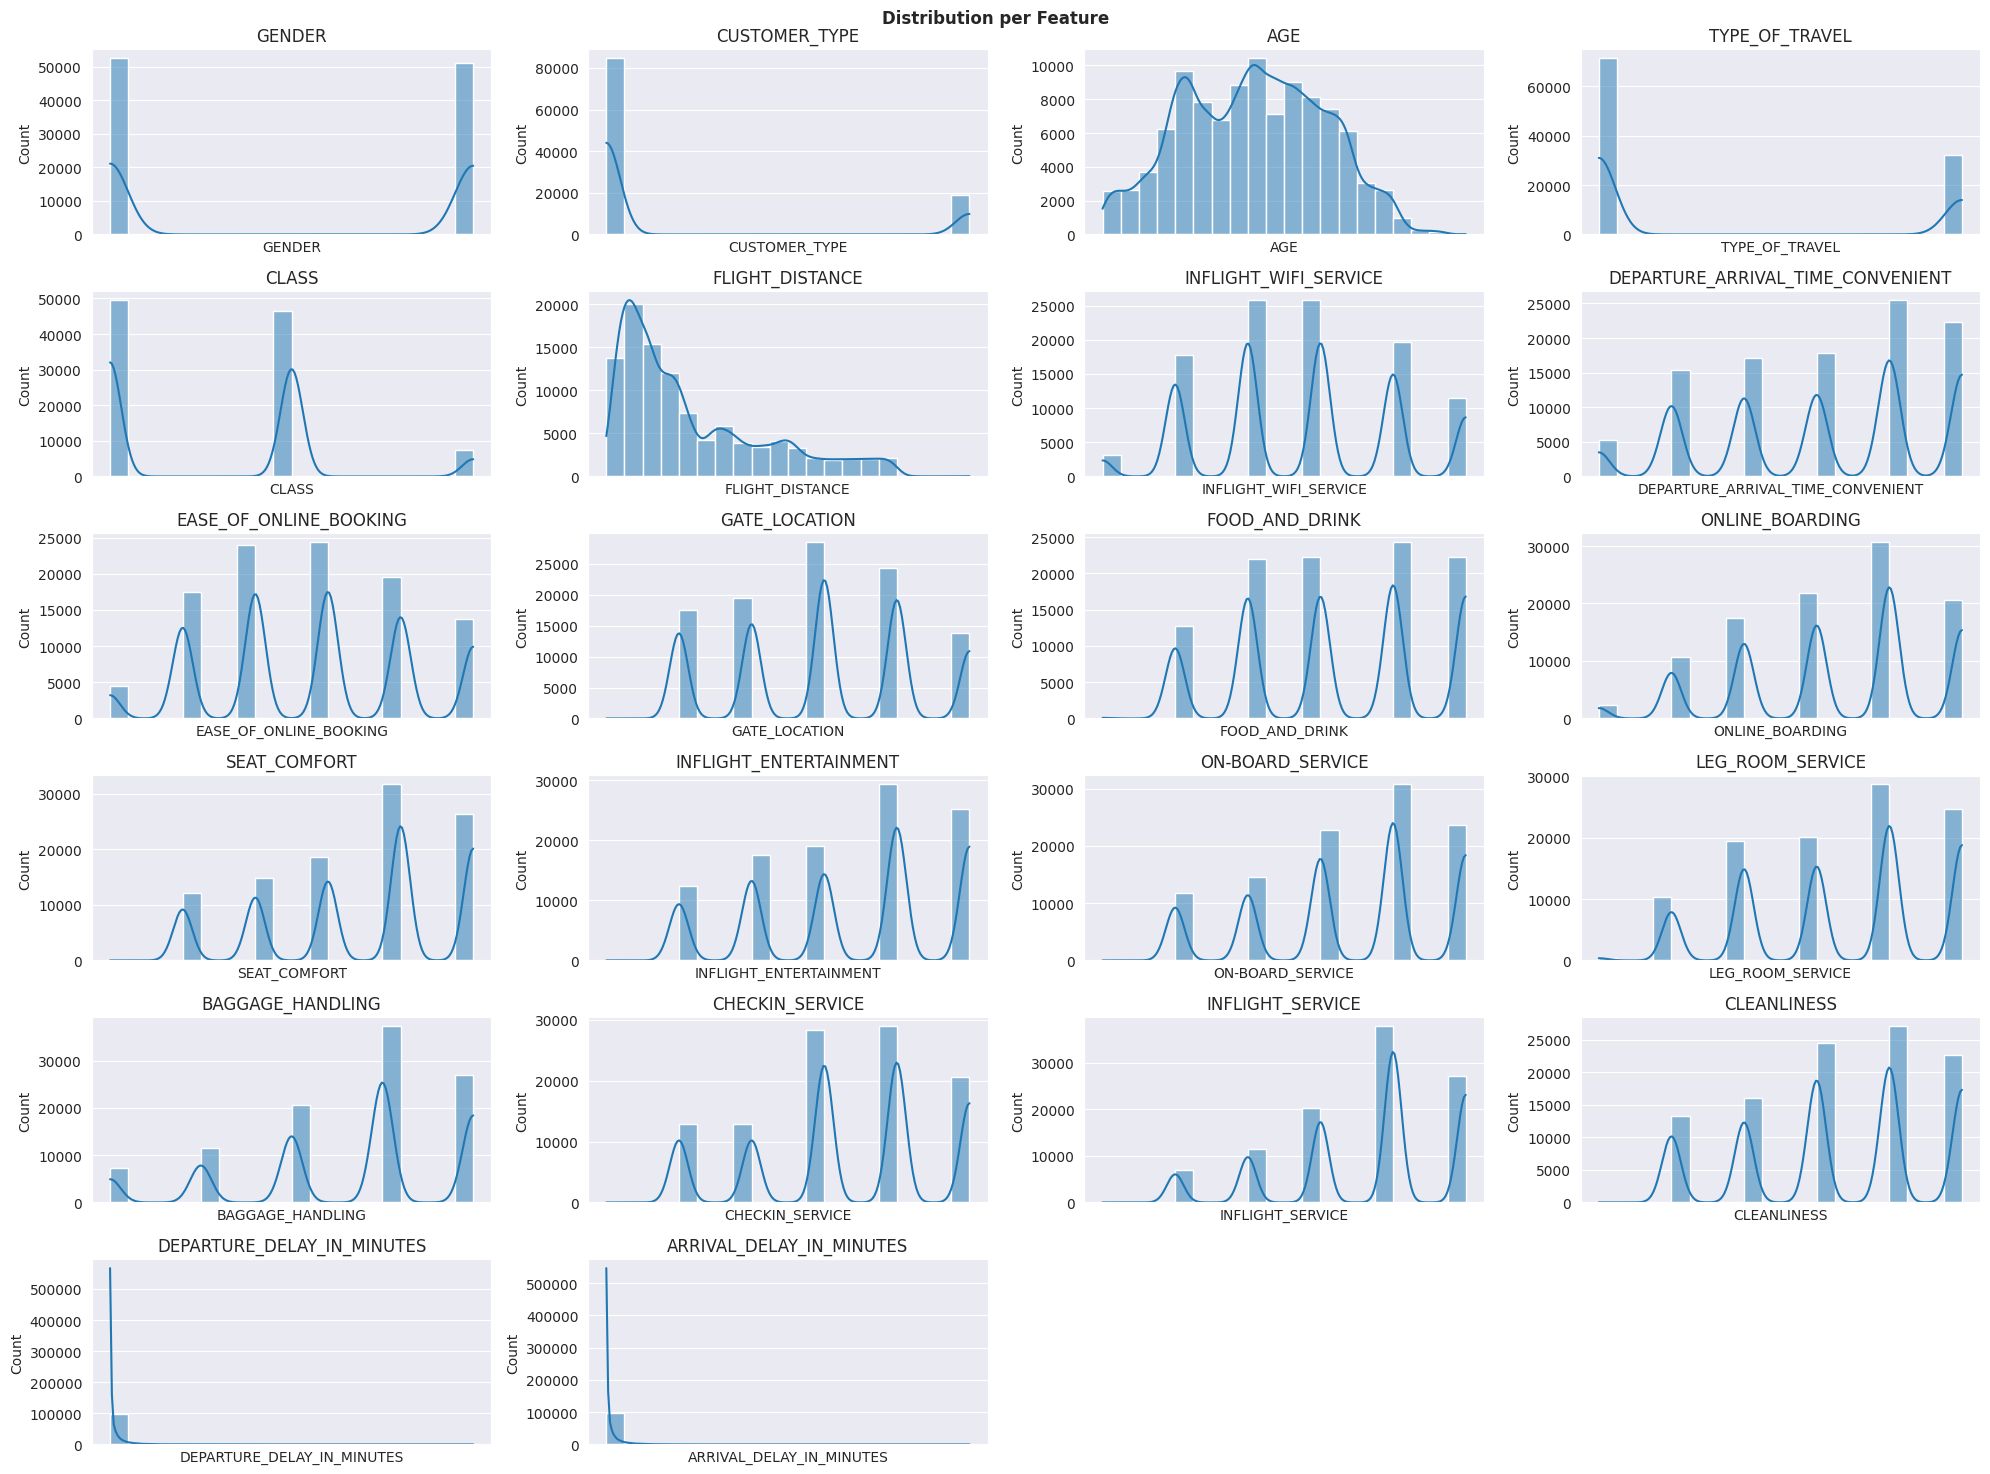

In [47]:
generate_histplots(X_train_standardScaled, kde=True)

#### Min/Max Scaler

In [48]:
min_max_scaler = MinMaxScaler()
X_train_minMaxScaled = min_max_scaler.fit_transform(X_train)
X_train_minMaxScaled = pd.DataFrame(X_train_minMaxScaled, columns=X_train.columns)

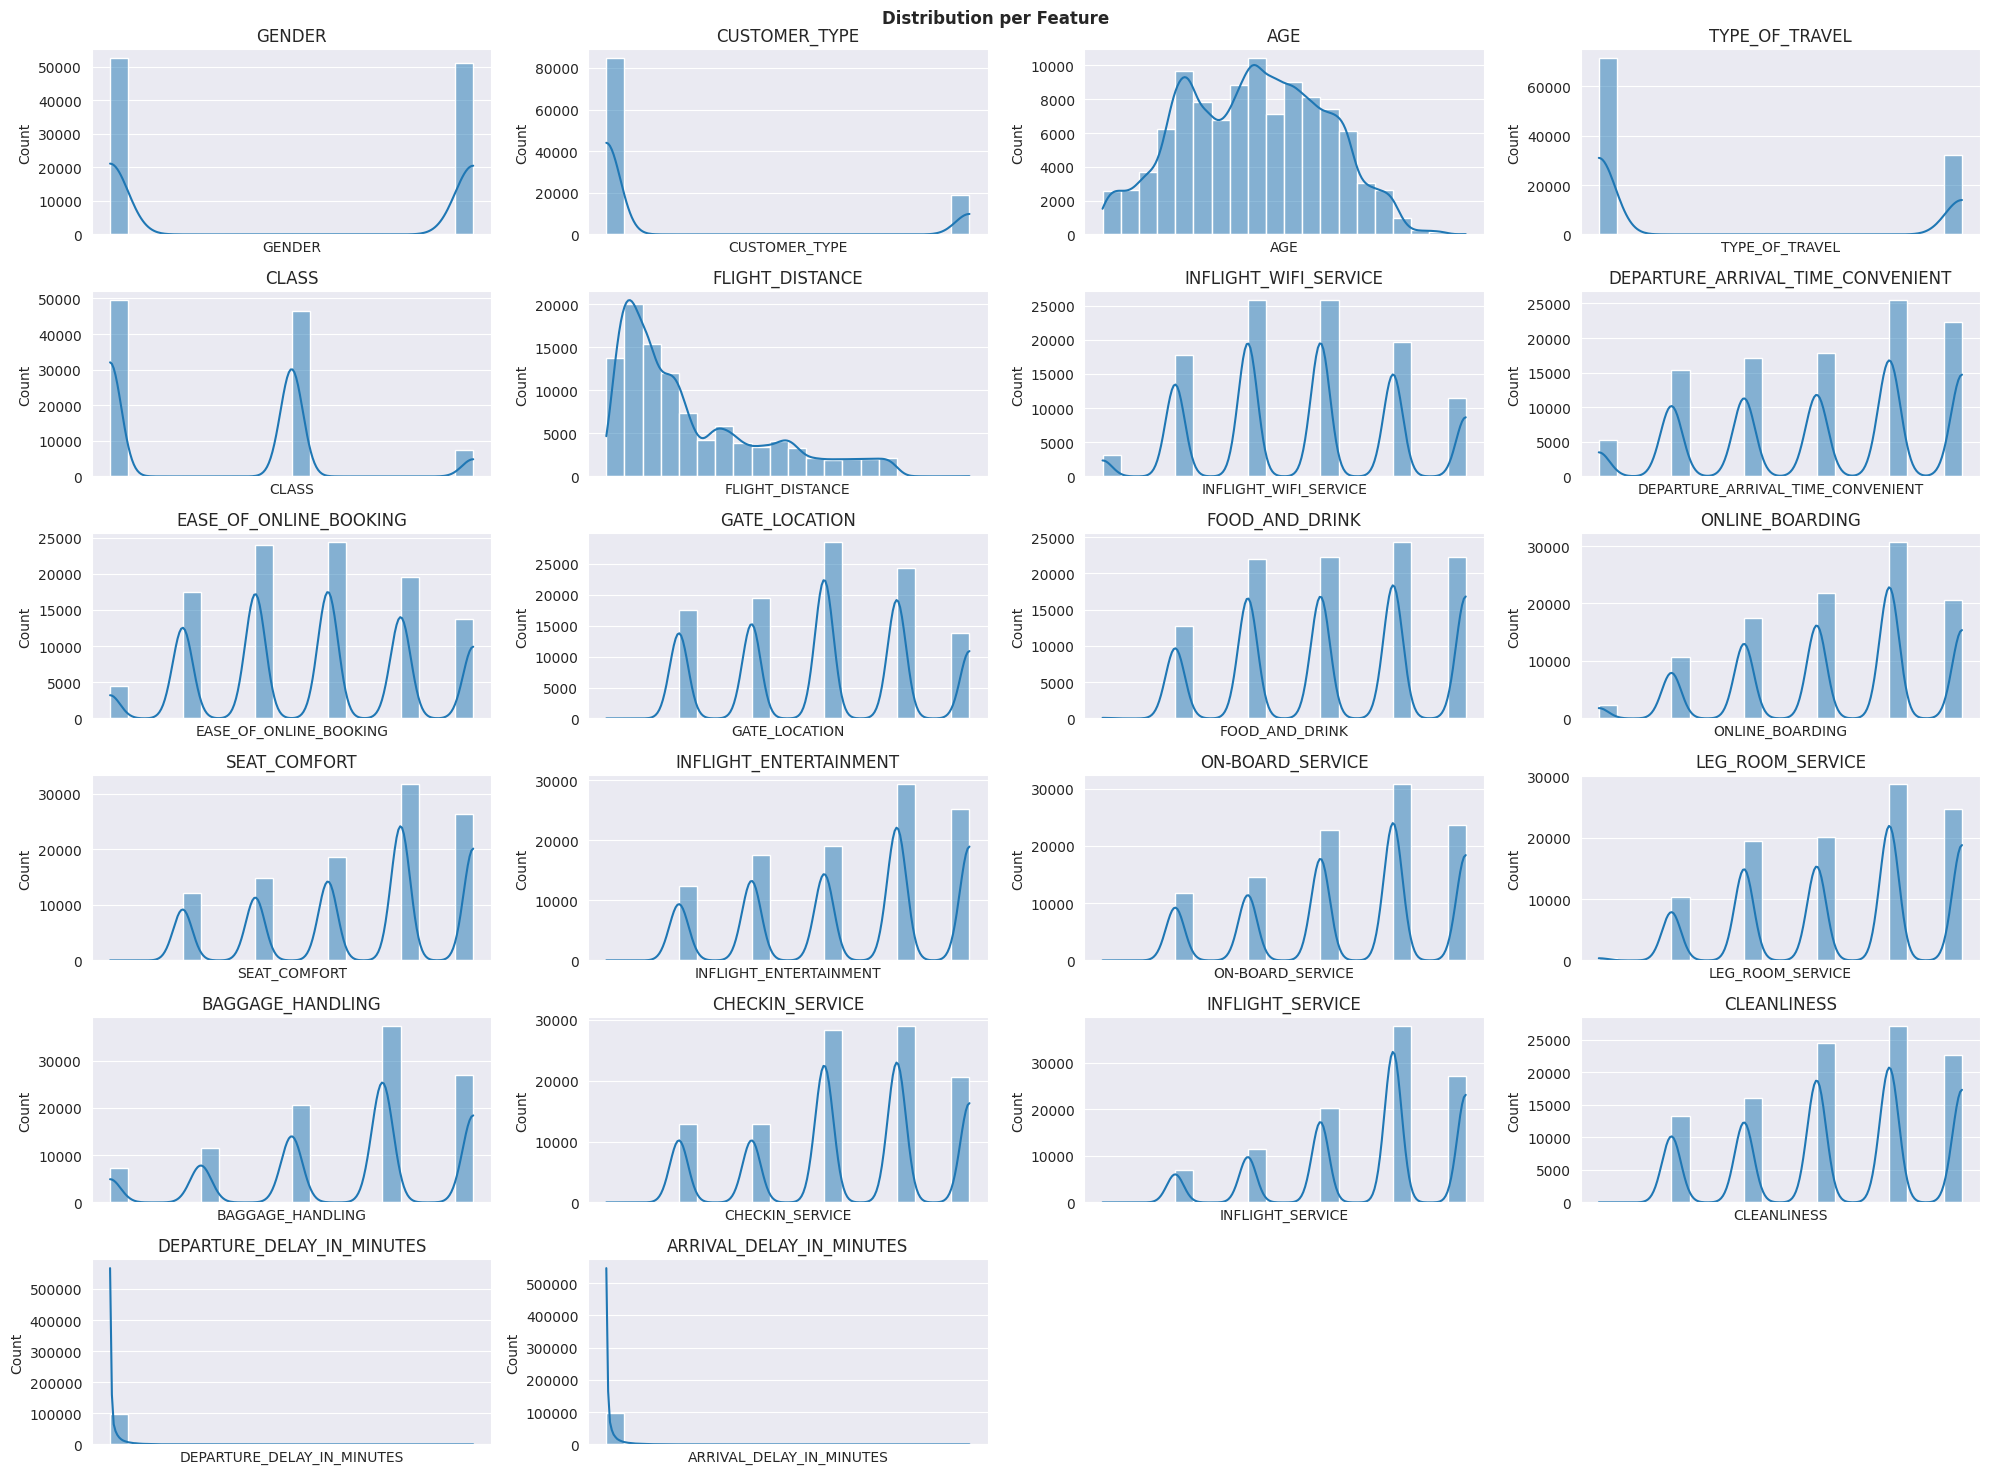

In [49]:
generate_histplots(X_train_minMaxScaled, kde=True)

#### Quantile Transform

In [50]:
quantile_transform = QuantileTransformer()
X_train_quantileTransformed = quantile_transform.fit_transform(X_train)
X_train_quantileTransformed = pd.DataFrame(X_train_quantileTransformed, columns=X_train.columns)

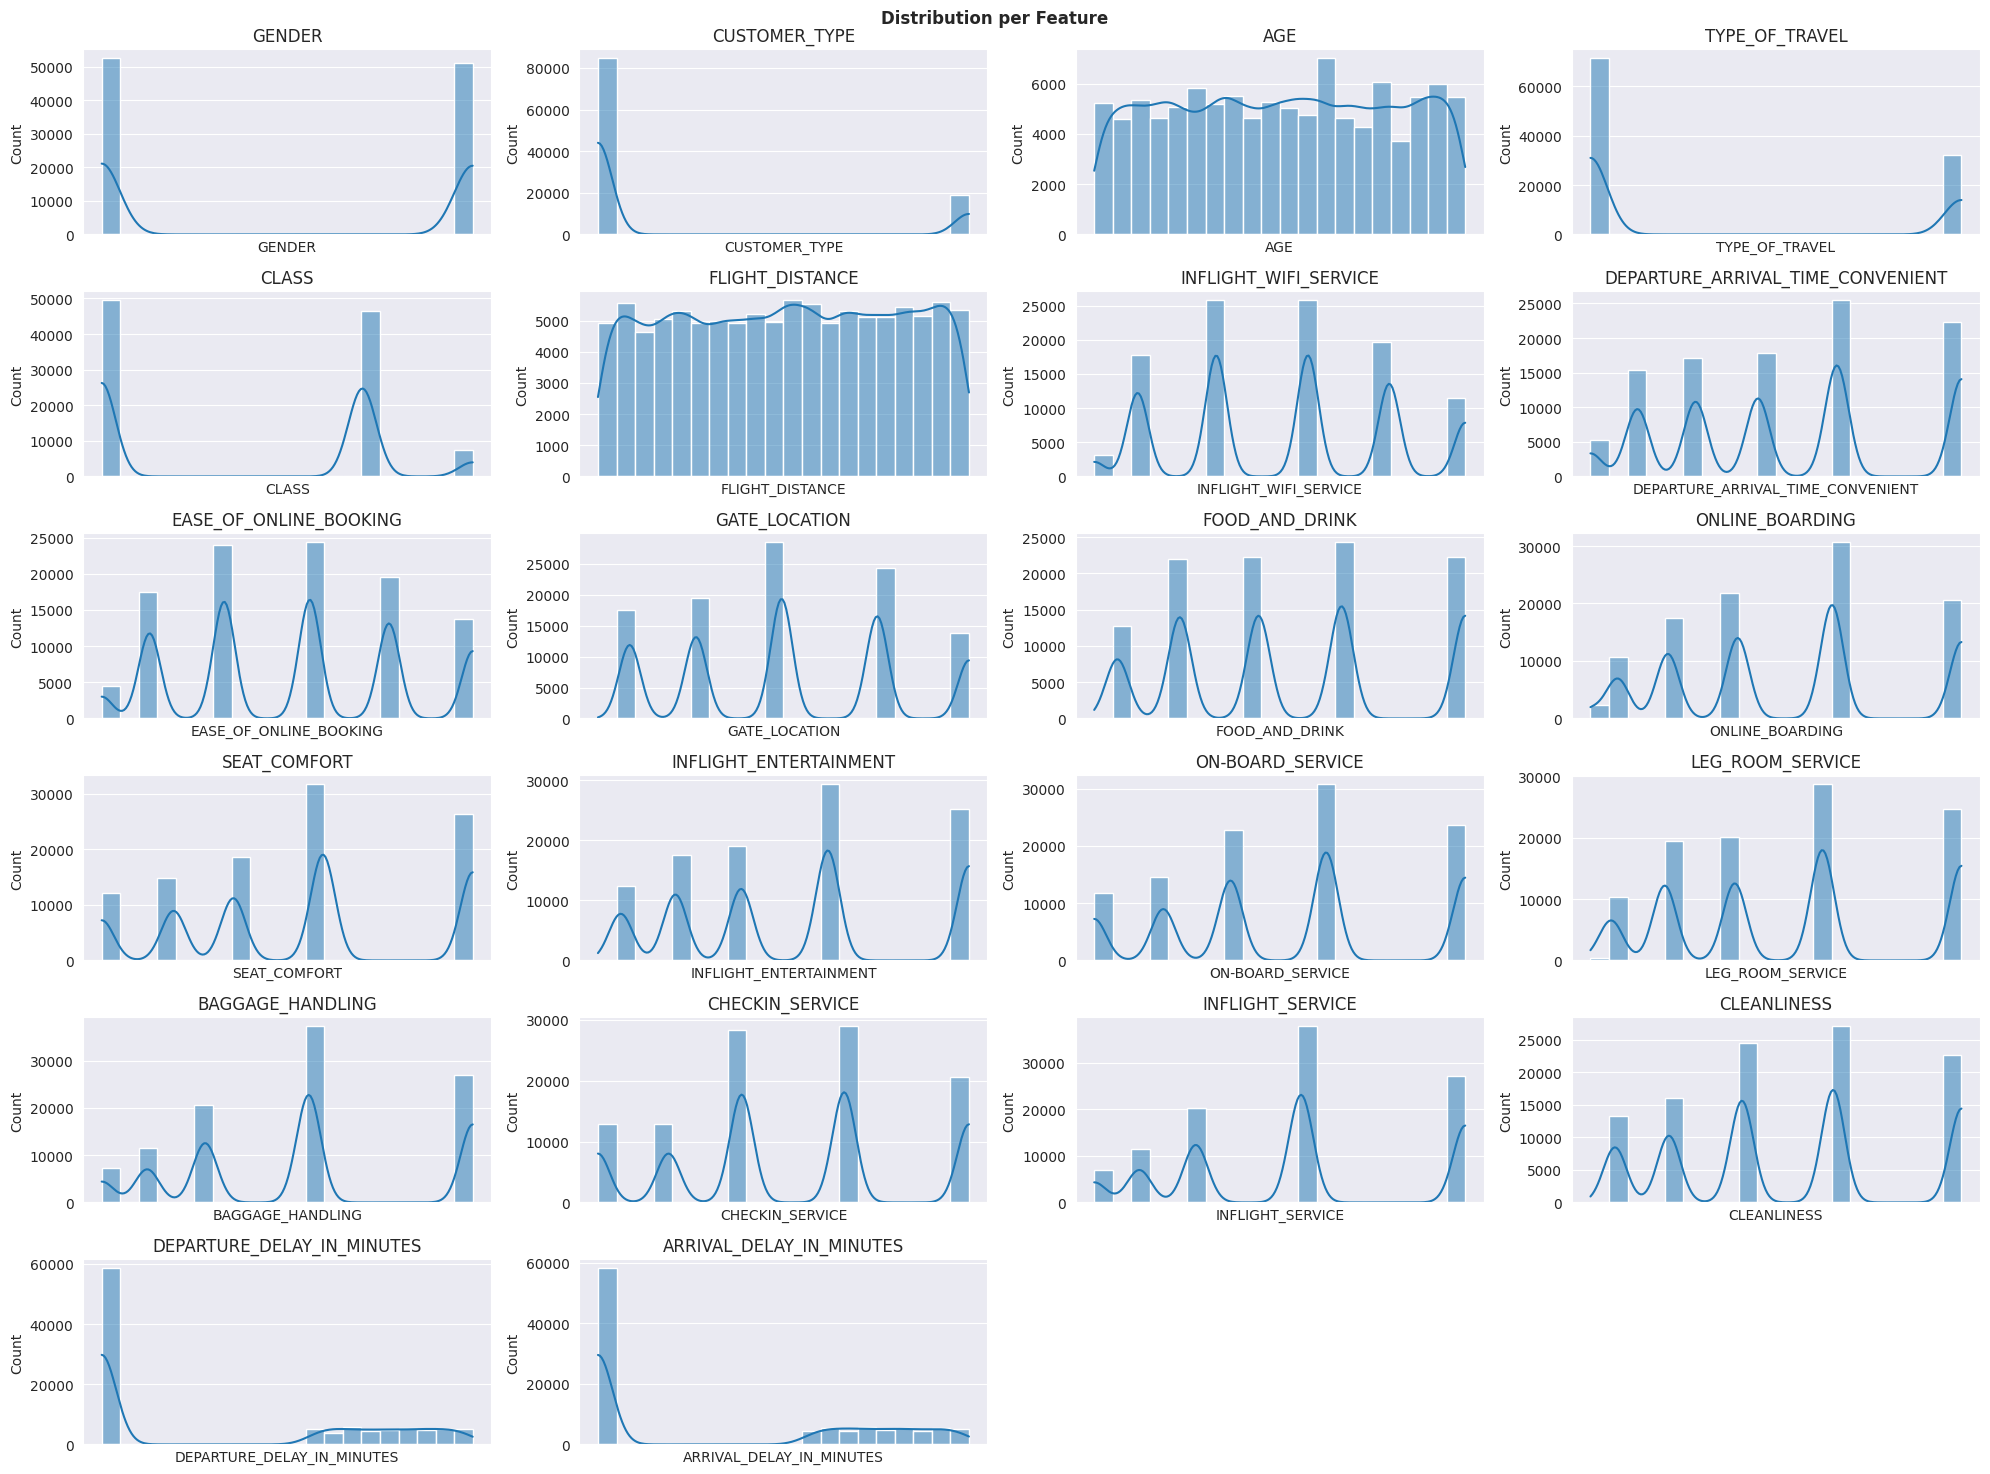

In [51]:
generate_histplots(X_train_quantileTransformed, kde=True)

#### Log Transform

In [52]:
log_transformer = FunctionTransformer(func=np.log1p)
X_train_logTransformed = log_transformer.fit_transform(X_train)
X_train_logTransformed = pd.DataFrame(X_train_logTransformed, columns=X_train.columns)

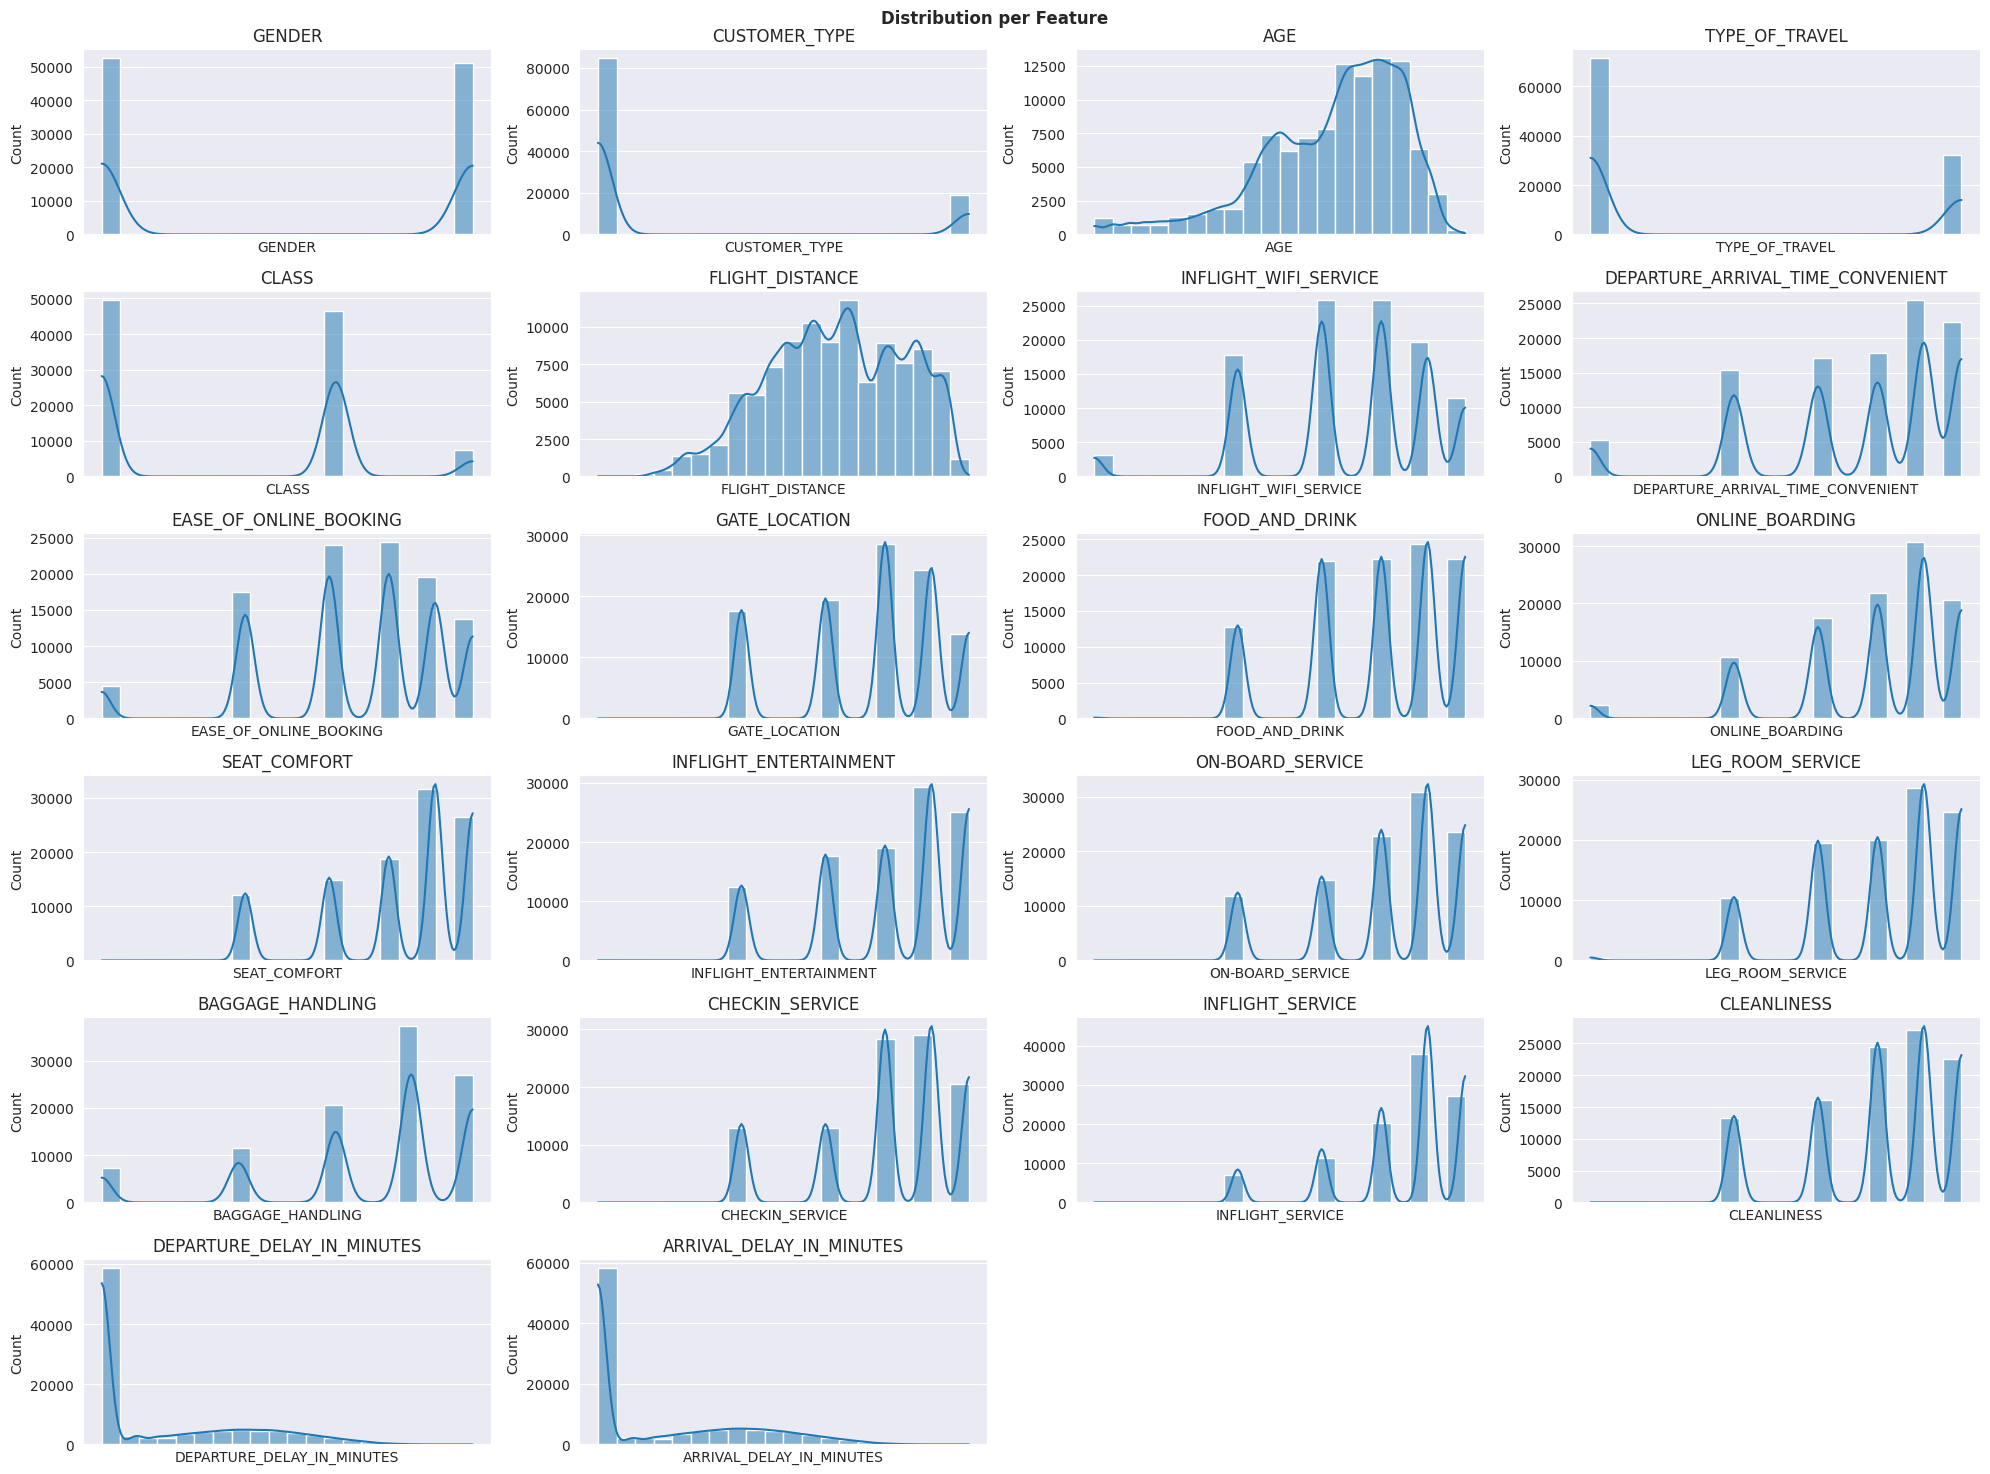

In [53]:
generate_histplots(X_train_logTransformed, kde=True)

Log transform seems to yield the best results for feature scaling in terms of the resulting distributions of the features. Standard scaler and min/max scaler struggled with arrival and departure delay in minutes features while quantile transform and log transform handled those features better.

## Apply Selected Transformation to Test Data

In [54]:
# Apply log transform to test data
X_test_logTransformed = log_transformer.transform(X_test)
X_test_logTransformed = pd.DataFrame(X_test_logTransformed, columns=X_test.columns)

## Feature Selection
Use Random Forest classifier to identify most important features and select those features.

In [55]:
# Train the Random Forest model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_logTransformed, y_train)

# Evaluate the model
accuracy_before = rf.score(X_test_logTransformed, y_test)
print(f'Accuracy before feature selection: {accuracy_before:.2f}')

Accuracy before feature selection: 0.96


In [56]:
importances = rf.feature_importances_
feature_names = X_train_logTransformed.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})

In [57]:
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
# print(feature_importance_df)

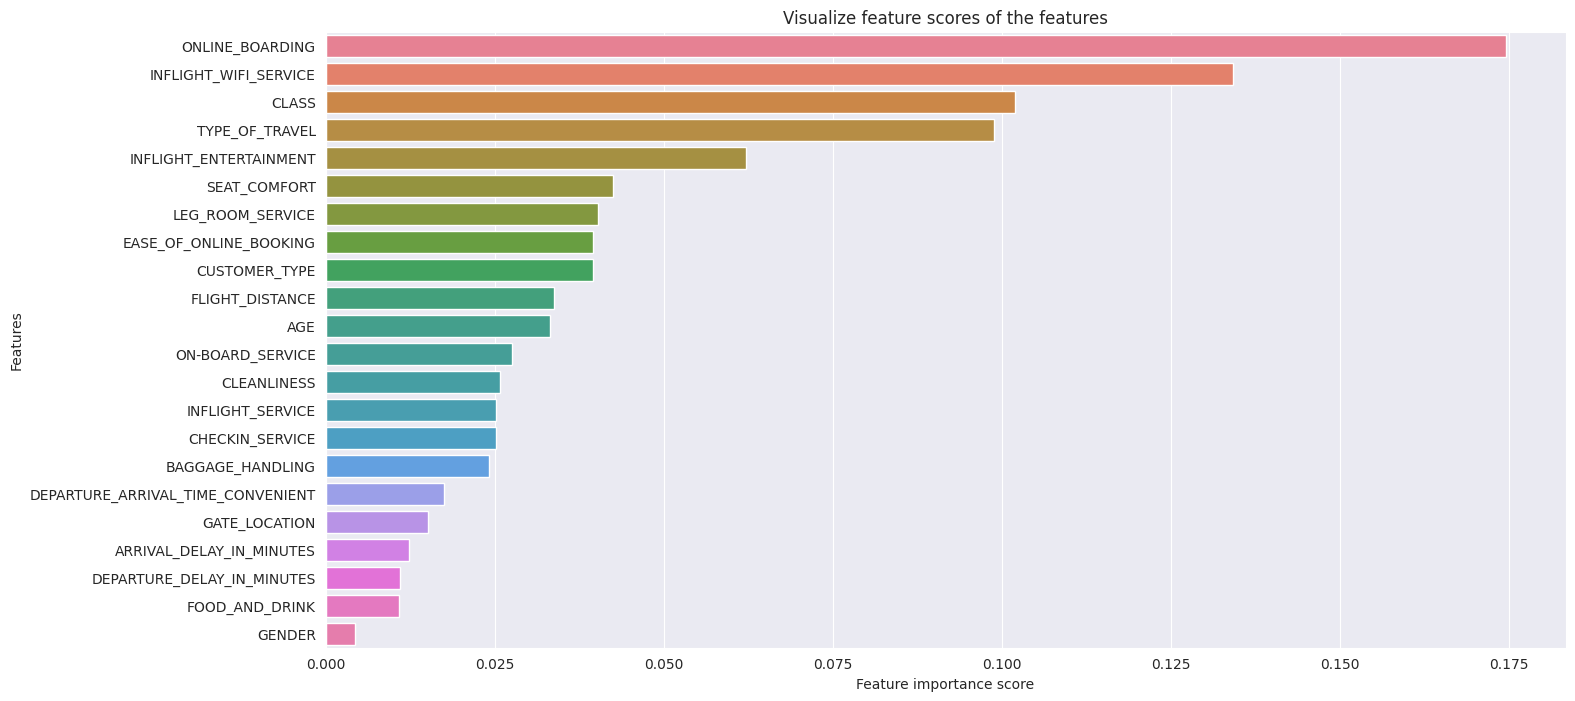

In [58]:
f, ax = plt.subplots(figsize=(16, 8))
ax = sns.barplot(data=feature_importance_df, x='Importance', y='Feature', hue='Feature', legend=False)
ax.set_title("Visualize feature scores of the features")
ax.set_xlabel("Feature importance score")
ax.set_ylabel("Features")
plt.show()

## Select and Train Model(s)
Since we are dealing with a binary classification problem, we do not need Softmax regression (which is applicable to multiple classes). Therefore, we will use logistic regression.

### Logistic Regression

In [59]:
logreg_model = LogisticRegression(
    max_iter=1000, 
    C=0.1, 
    penalty="l2",
    random_state=42
)
logreg_model.fit(X_train_logTransformed, y_train)

LogisticRegression(C=0.1, max_iter=1000, random_state=42)

## Evaluate and Fine-Tune Model(s)

### Evaluation

In [60]:
# Compute confusion matrix
def plot_cm(cm, model_name, labels):
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
    disp.plot()
    plt.gca().grid(False)
    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

In [61]:
# NOTE: Default threshold = 0.5 for binary classification
def plot_precision_recall_curve(y_true, y_scores, model_name, threshold=0.5):
    precisions, recalls, thresholds = precision_recall_curve(y_true, y_scores)
    plt.plot(thresholds, precisions[:-1], 'b--', label='Precision', linewidth=2)
    plt.plot(thresholds, recalls[:-1], 'g--', label='Recall', linewidth=2)
    plt.vlines(threshold, 0, 1.0, 'k', 'dotted', label='Threshold')

    # Add intersection points, axis label, legend, and title
    idx = (thresholds >= threshold).argmax()  # first index ≥ threshold
    plt.plot(thresholds[idx], precisions[idx], "bo")
    plt.plot(thresholds[idx], recalls[idx], "go")
    plt.xlabel("Threshold")
    plt.legend(loc="lower left")
    plt.title(f"{model_name} Precision Recall Curve")
    plt.show()

In [62]:
def plot_roc_curve(y_true, y_scores, model_name):
    # ROC Curve
    fpr, tpr, _ = roc_curve(y_true, y_scores)
    plt.figure(figsize=(6, 4))
    plt.plot(fpr, tpr, color='blue', label=f'ROC Curve (AUC = {roc_auc_score(y_true, y_scores):.4f})')
    plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
    plt.title(f'{model_name} ROC Curve')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.legend(loc='best')
    plt.show()

In [63]:
def quick_evaluate(model, test_data, test_labels, model_name, display_labels):
    # Make predictions with the given model
    y_pred = model.predict(test_data)
    y_scores = model.predict_proba(test_data)
    
    # Calculate and print accuraacy on training data
    accuracy = accuracy_score(test_labels, y_pred)
    
    print(f">>> {model_name} accuracy: {accuracy}")
    cm = confusion_matrix(test_labels, y_pred)
    
    # Print classification report for detailed metrics per class
    print("Classification Report:\n", classification_report(test_labels, y_pred))
    
    plot_cm(cm, model_name, display_labels)
    plot_precision_recall_curve(y_test, y_scores[:,-1], model_name)
    plot_roc_curve(y_test, y_scores[:,-1], model_name)

 #### Logistic Regression

>>> Logistic Regression accuracy: 0.8547870080716796
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.87     14528
           1       0.85      0.81      0.83     11365

    accuracy                           0.85     25893
   macro avg       0.85      0.85      0.85     25893
weighted avg       0.85      0.85      0.85     25893



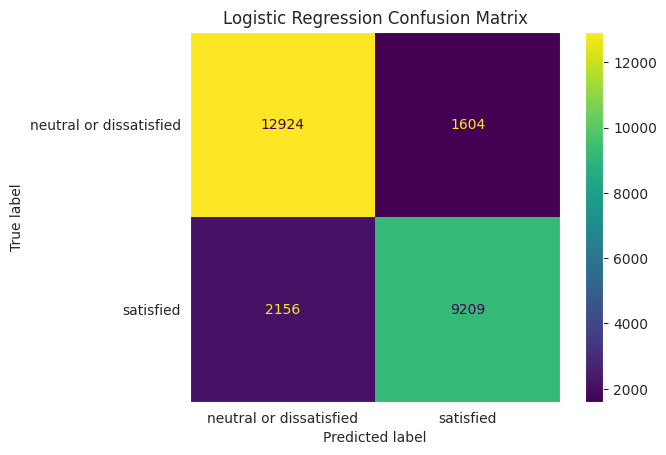

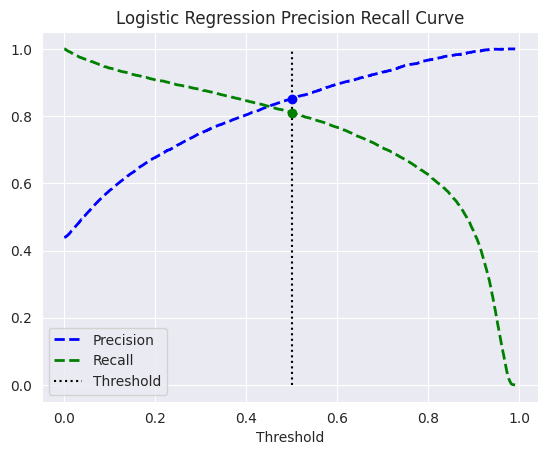

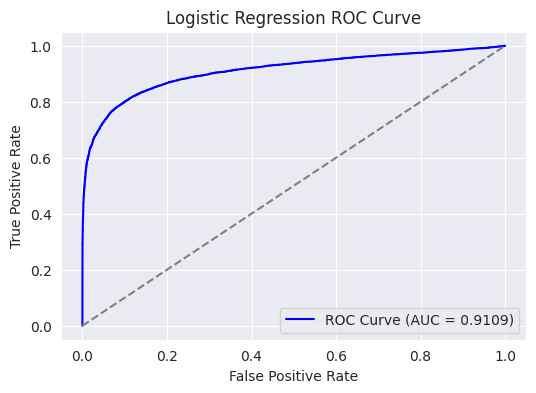

In [64]:
# logreg_model
quick_evaluate(
    model=logreg_model,
    test_data=X_test_logTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Logistic Regression"
)

### Fine-Tuning

#### Grid Search with Cross Validation

In [65]:
# Define the parameter grid
# ================= ============================== ======================
# solver            penalty                        multinomial multiclass
# ================= ============================== ======================
# 'lbfgs'           'l2', None                     yes
# 'liblinear'       'l1', 'l2'                     no
# 'newton-cg'       'l2', None                     yes
# 'newton-cholesky' 'l2', None                     no
# 'sag'             'l2', None                     yes
# 'saga'            'elasticnet', 'l1', 'l2', None yes
# ================= ============================== ======================
logreg_param_grid = {
    # 'penalty': ['l1', 'l2', 'elasticnet'],
    'penalty': ['elasticnet'],
    'C': [1, 5, 50, 1000],
    'max_iter': [50, 100, 1000, 10000],
    'solver': ['saga'],
    'l1_ratio': [0.1, 0.25, 0.5, 0.75],
    'random_state': [42],
}

# Initialize Logistic Regression model
logreg_model = LogisticRegression()

# Initialize GridSearchCV
grid_search_logreg = GridSearchCV(
    estimator=logreg_model, 
    param_grid=logreg_param_grid, 
    cv=5,
    scoring='accuracy', 
    n_jobs=-1
)

# Perform Grid Search on the training data
grid_search_logreg.fit(X_train_logTransformed, y_train)

# Retrieve the best parameters
best_params_logreg = grid_search_logreg.best_params_
print(f"Best parameters for Logistic Regression with Grid Search: {best_params_logreg}")

Best parameters for Logistic Regression with Grid Search: {'C': 1, 'l1_ratio': 0.25, 'max_iter': 50, 'penalty': 'elasticnet', 'random_state': 42, 'solver': 'saga'}


>>> Fine-Tuned Logistic Regression (Grid Search CV) accuracy: 0.8549028695014097
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.87     14528
           1       0.85      0.81      0.83     11365

    accuracy                           0.85     25893
   macro avg       0.85      0.85      0.85     25893
weighted avg       0.85      0.85      0.85     25893



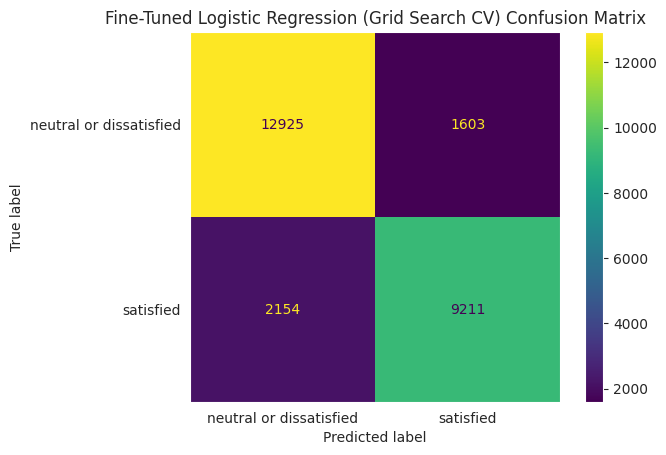

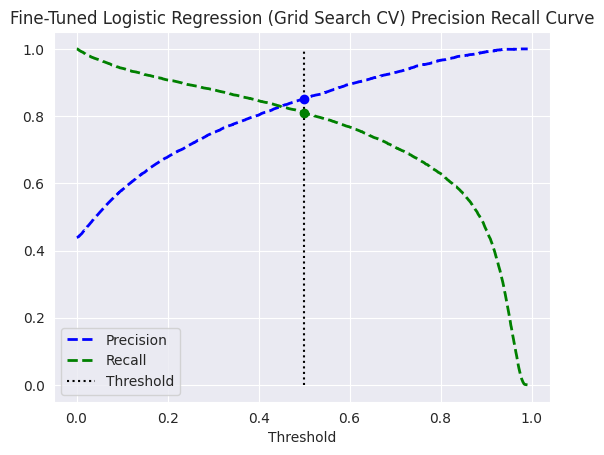

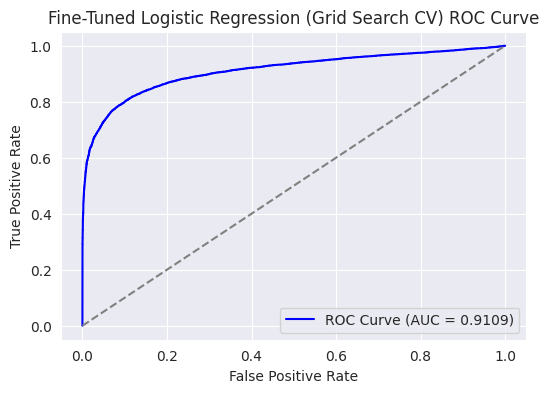

In [66]:
quick_evaluate(
    model=grid_search_logreg.best_estimator_,
    test_data=X_test_logTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Fine-Tuned Logistic Regression (Grid Search CV)"
)

#### Random Search with Cross Validation

In [67]:
# RandomizedSearchCV
# See page 94 in Hands-On Machine Learning with Scikit-Learn, Keras & TensorFlow textbook
logreg_param_rand_search = {
    'penalty': ['l1', 'l2', 'elasticnet'],
    'C': randint(low=1, high=50),
    'max_iter': randint(low=50, high=1000),
    'solver': ['saga'],
    'random_state': [42],
}

rnd_search_logreg = RandomizedSearchCV(
    LogisticRegression(),
    logreg_param_rand_search,
    cv=5,
    scoring='accuracy', 
    n_jobs=-1
)

# Perform Random Search on the training data
rnd_search_logreg.fit(X_train_logTransformed, y_train)

# Retrieve the best parameters
best_params_rnd_search_logreg = rnd_search_logreg.best_params_
print(f"Best parameters for Logistic Regression with Random Search: {best_params_rnd_search_logreg}")

Best parameters for Logistic Regression with Random Search: {'C': 30, 'max_iter': 212, 'penalty': 'l1', 'random_state': 42, 'solver': 'saga'}


>>> Fine-Tuned Logistic Regression (Random Search CV) accuracy: 0.8550187309311397
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.87     14528
           1       0.85      0.81      0.83     11365

    accuracy                           0.86     25893
   macro avg       0.85      0.85      0.85     25893
weighted avg       0.85      0.86      0.85     25893



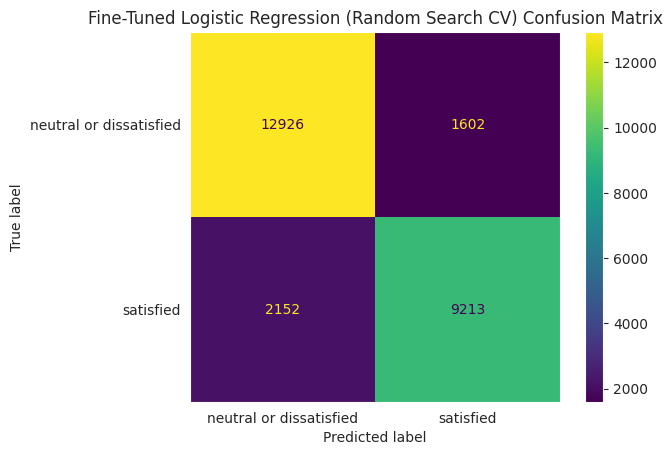

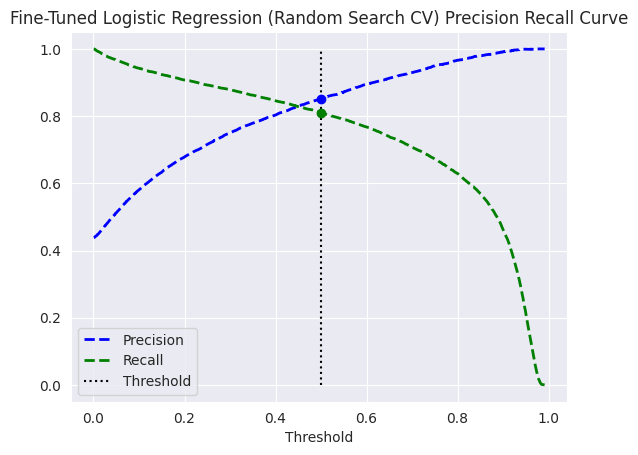

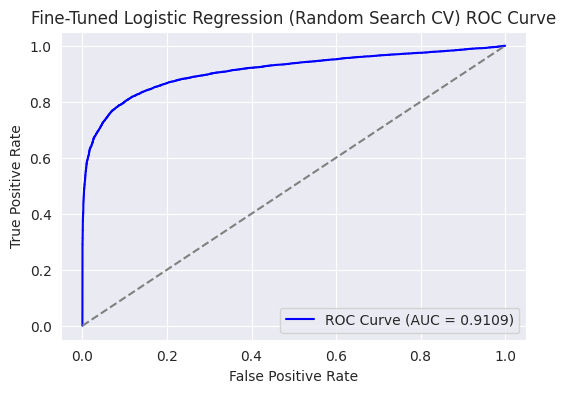

In [68]:
quick_evaluate(
    model=rnd_search_logreg.best_estimator_,
    test_data=X_test_logTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Fine-Tuned Logistic Regression (Random Search CV)"
)

#### Principal Component Analysis (PCA)

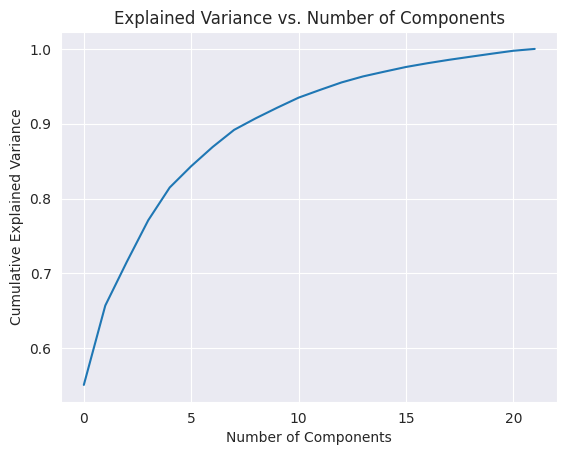

In [69]:
pca = PCA()
pca.fit(X_train_logTransformed)

# Calculate the explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_

# Plot the explained variance ratio
plt.plot(np.cumsum(explained_variance_ratio))
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.show()

Using the **Elbow Method**, we can see that the optimal number of features is between `10` and `15`, which is where the explained variance starts to level off.

In [70]:
# With threshold method
# Choose the number of components that explain 95% of the variance
threshold = 0.95
n_components = np.argmax(np.cumsum(explained_variance_ratio) >= threshold) + 1
print(f'Using {n_components} principal components will explain {round(threshold*100)}% of the variance')

Using 13 principal components will explain 95% of the variance


Given `13` principal components explains `95%` of the variance in the dataset and this finding is in alignment with the observations from the **Elbow Method** since `13` is between `10` and `15`, we will select `13` as the number of components.

**NOTE** Rather than manually applying a threshold, sklearn PCA supports passing in a threshold as the n_components value. For example `PCA(n_components=0.95)`

In [71]:
# Create a new PCA object with the chosen number of components
pca = PCA(n_components=n_components)

# Fit and transform the data
X_pca = pca.fit_transform(X_train_logTransformed)

In [72]:
# logreg_pca_pipeline = Pipeline([
#     ('pca', PCA(n_components=n_components)),
#     ('logreg', LogisticRegression(**best_params_logreg)),
# ])

logreg_pca_pipeline = Pipeline([
    ('pca', PCA(n_components=n_components)),
    ('grid_search_logreg', GridSearchCV(
        estimator=LogisticRegression(),
        param_grid=logreg_param_grid, 
        cv=5,
        scoring='accuracy', 
        n_jobs=-1
    ))
])

logreg_pca_pipeline.fit(X_train_logTransformed, y_train)

Pipeline(steps=[('pca', PCA(n_components=13)),
                ('grid_search_logreg',
                 GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
                              param_grid={'C': [1, 5, 50, 1000],
                                          'l1_ratio': [0.1, 0.25, 0.5, 0.75],
                                          'max_iter': [50, 100, 1000, 10000],
                                          'penalty': ['elasticnet'],
                                          'random_state': [42],
                                          'solver': ['saga']},
                              scoring='accuracy'))])

In [73]:
# Retrieve the best parameters
best_params_logreg_pca = logreg_pca_pipeline['grid_search_logreg'].best_params_
print(f"Best parameters for Logistic Regression with PCA and GridSearchCV: {best_params_logreg_pca}")

Best parameters for Logistic Regression with PCA and GridSearchCV: {'C': 5, 'l1_ratio': 0.1, 'max_iter': 50, 'penalty': 'elasticnet', 'random_state': 42, 'solver': 'saga'}


>>> Fine-Tuned Logistic Regression (PCA and Grid Search CV) accuracy: 0.8213030548796972
Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84     14528
           1       0.81      0.77      0.79     11365

    accuracy                           0.82     25893
   macro avg       0.82      0.82      0.82     25893
weighted avg       0.82      0.82      0.82     25893



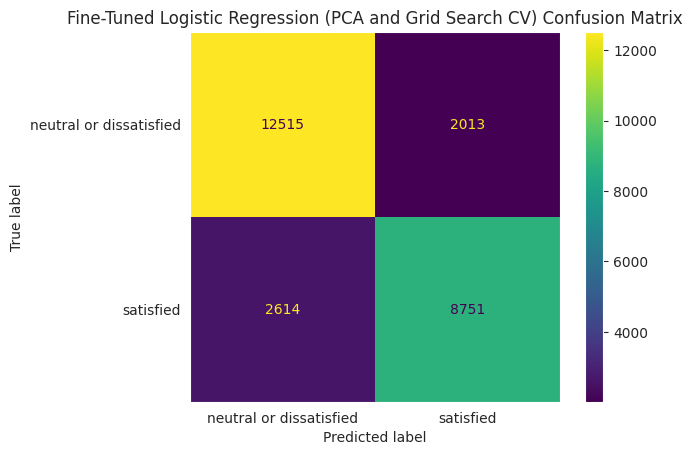

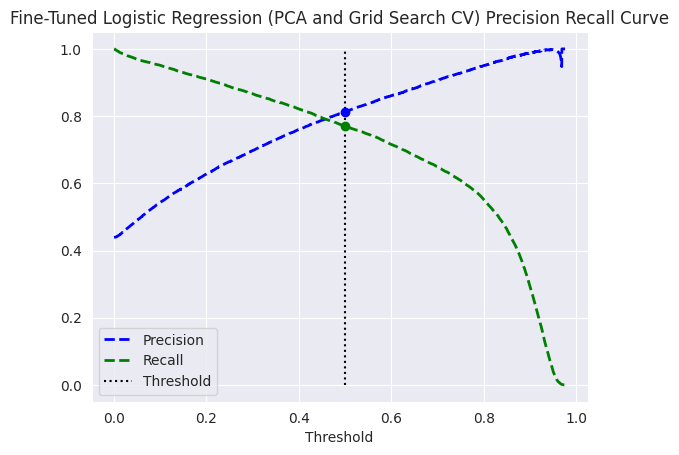

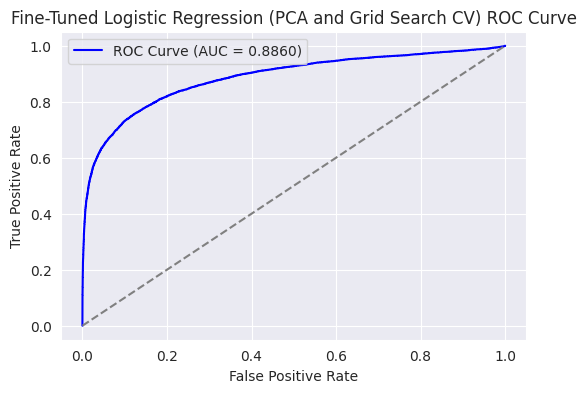

In [74]:
X_test_logTransformed_pca = logreg_pca_pipeline['pca'].transform(X_test_logTransformed)

# quick_evaluate(
#     model=logreg_pca_pipeline['logreg'],
#     test_data=X_test_logTransformed_pca,
#     test_labels=y_test,
#     display_labels=list(label_to_id.keys()),
#     model_name="Fine-Tuned Logistic Regression (Grid Search CV)"
# )
quick_evaluate(
    model=logreg_pca_pipeline['grid_search_logreg'].best_estimator_,
    test_data=X_test_logTransformed_pca,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Fine-Tuned Logistic Regression (PCA and Grid Search CV)"
)

Unfortunately, using PCA and GridSearchCV does not improve the accuracy of the Logistic Regression model. We could iteratively try a different number of components through grid search but it is unlikely we will see better performance than the results of grid search on all available features.

#### Manual Hyperparameter Tuning

>>> Manual Hyperparameter Tuned Logistic Regression accuracy: 0.8549414899779864
Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.89      0.87     14528
           1       0.85      0.81      0.83     11365

    accuracy                           0.85     25893
   macro avg       0.85      0.85      0.85     25893
weighted avg       0.85      0.85      0.85     25893



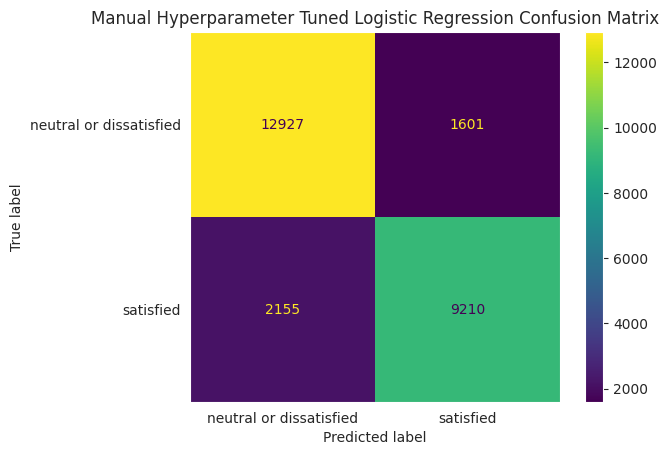

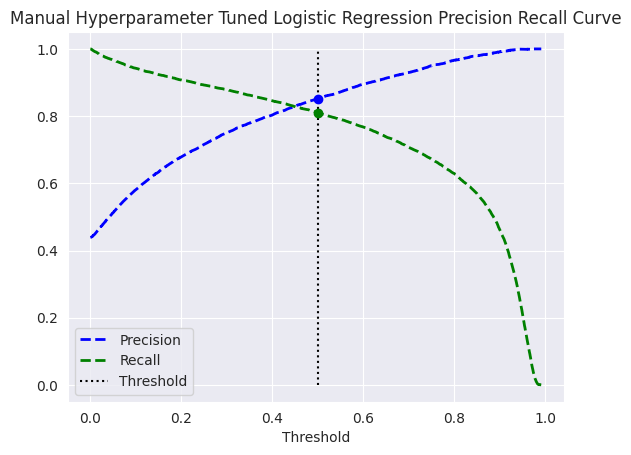

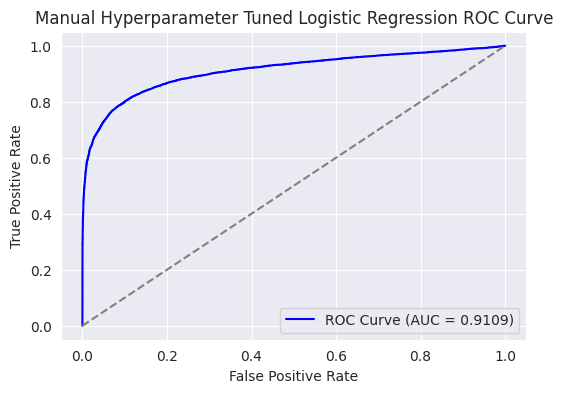

In [76]:
tuned_logreg_model = LogisticRegression(
    max_iter=1000, 
    C=1, 
    solver='saga',
    penalty="elasticnet",
    l1_ratio=0.5, # equally divide use of l1 and l2 norm using 0.5
    random_state=42
)
tuned_logreg_model.fit(X_train_logTransformed, y_train)

quick_evaluate(
    model=tuned_logreg_model,
    test_data=X_test_logTransformed,
    test_labels=y_test,
    display_labels=list(label_to_id.keys()),
    model_name="Manual Hyperparameter Tuned Logistic Regression"
)

## Conclusion/Insights
After cleaning the data and preparing the data for training, it was evident that log transform held the most promise in terms of normally distributed features. We were able to use a random forest classifier to identify the most important (statistically significant) features, which helped to gain insight on which features have the most influence on the labels. For example, the top 5 most important features were:
1) `ONLINE_BOARDING`
2) `INFLIGHT_WIFI_SERVICE`
3) `CLASS`
4) `TYPE_OF_TRAVEL`
5) `INFLIGHT_ENTERTAINMENT`

After identifying important features, we moved on to training a logistic regression model. The base model yielded promising results with approximately `85%` accuracy. Various fine-tuning techniques were applied such as grid search, random search, PCA with grid search, and manual hyperparameter tuning. Unfortunately, through exhaustive efforts, none of the fine-tuning approaches improved the model accuracy. This is most likely due to how logistic regression works. Accuracy is not the best metric to use to evaluate logistic regression because the goal of logistic regression is to minimize loss. 

In conclusion, while logistic regression is a good start, ensemble classifiers such as `random forest`, `AdaBoost`, `GradientBoost`, and `XGBoost` are likely to perform the best on this dataset. We can see evidence of this with the random forest model used to identify feature importance - the model had an accuracy of `96%` with all features included.